# Notebook 03 — Clustering de perfiles bancarios en Argentina

**Autora:** Victoria Di Liscia
**Programa:** Maestría en Explotación de Datos y Descubrimiento del Conocimiento — FCEN, UBA
**Entrega III** — Data Mining

**Dataset:** 52 bancos (excluidos Bank of China, JPMorgan, BNP Paribas, Cetelem)
**Período:** promedio de cortes Dic-2023 / Dic-2024 / Dic-2025
**Pipeline:** PCA → K-Means → DBSCAN

## 1. Setup

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ROOT = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
PROCESSED = ROOT / "data" / "processed"

SEED = 42
np.random.seed(SEED)
print(f"ROOT: {ROOT}")

ROOT: /Users/victoria/Documents/Maestria/tesis-perfiles-bancarios


## 2. Carga y preparación de datos

### 2.1 Carga del panel y exclusión de bancos problemáticos

In [2]:
panel = pd.read_csv(PROCESSED / "panel_ratios.csv")

# Bancos mayoristas / sin cartera minorista relevante: >40% missings en variables clave
EXCLUIDOS = {131: "Bank of China", 165: "JPMorgan", 266: "BNP Paribas", 331: "Cetelem"}
panel = panel[~panel["codigo_entidad"].isin(EXCLUIDOS)].copy()

print(f"Bancos en análisis : {panel['codigo_entidad'].nunique()}")
print(f"Cortes disponibles : {sorted(panel['corte'].unique())}")
print(f"Total observaciones: {len(panel)} ({panel['codigo_entidad'].nunique()} bancos × {panel['corte'].nunique()} cortes)")
print()
print("Distribución por tipo de entidad:")
print(panel.drop_duplicates("codigo_entidad")["tipo_entidad"].value_counts())

Bancos en análisis : 52
Cortes disponibles : ['Dic-2023', 'Dic-2024', 'Dic-2025']
Total observaciones: 156 (52 bancos × 3 cortes)

Distribución por tipo de entidad:
tipo_entidad
privado_nacional    30
publico             17
extranjero           5
Name: count, dtype: int64


### 2.2 Variables adicionales

In [3]:
# Variables que no vienen calculadas en panel_ratios
panel["log_activo"] = np.log(panel["activo"])
panel["titulos_sobre_activo"] = panel["TÍTULOS PÚBLICOS Y PRIVADOS"].abs() / panel["activo"]
panel["patrimonio_sobre_activo"] = panel["patrimonio"].abs() / panel["activo"]
panel["log_activo_por_empleado"] = np.log(panel["activo_por_empleado"].clip(lower=1))

print("Variables adicionales creadas: log_activo, titulos_sobre_activo, patrimonio_sobre_activo, log_activo_por_empleado")

Variables adicionales creadas: log_activo, titulos_sobre_activo, patrimonio_sobre_activo, log_activo_por_empleado


### 2.3 Vector de features

Se seleccionan **21 variables** agrupadas en tres bloques:

| Bloque | Variables | Fuente |
|--------|-----------|--------|
| **Balance y rentabilidad** (10 continuas) | log_activo, prestamos_sobre_activo, titulos_sobre_activo, depositos_sobre_activo, patrimonio_sobre_activo, roa, liquidez, eficiencia, cartera_irregular, log_activo_por_empleado | Scraper BCRA |
| **Oferta de productos** (11 binarias) | ofrece_hipoteca, hipoteca_uva, ofrece_personal, ofrece_prendario, ofrece_pfijo, pfijo_uva, ofrece_paquete, paquete_tiene_premium, ofrece_tarjeta, tarjeta_tiene_premium, caja_apertura_simplificada | Régimen de Transparencia Sección 36 |

In [4]:
FEATURES_CONTINUAS = [
    "log_activo",
    "prestamos_sobre_activo",
    "titulos_sobre_activo",
    "depositos_sobre_activo",
    "patrimonio_sobre_activo",
    "roa",
    "liquidez",
    "eficiencia",
    "cartera_irregular",
    "log_activo_por_empleado",
]

FEATURES_BINARIAS = [
    "ofrece_hipoteca",
    "hipoteca_uva",
    "ofrece_personal",
    "ofrece_prendario",
    "ofrece_pfijo",
    "pfijo_uva",
    "ofrece_paquete",
    "paquete_tiene_premium",
    "ofrece_tarjeta",
    "tarjeta_tiene_premium",
    "caja_apertura_simplificada",
]

FEATURES = FEATURES_CONTINUAS + FEATURES_BINARIAS
META = ["codigo_entidad", "nombre_banco", "tipo_entidad"]

print(f"Features continuas : {len(FEATURES_CONTINUAS)}")
print(f"Features binarias  : {len(FEATURES_BINARIAS)}")
print(f"Total features     : {len(FEATURES)}")

Features continuas : 10
Features binarias  : 11
Total features     : 21


### 2.4 Promedio de los tres cortes

In [5]:
# Una fila por banco: promedio de Dic-2023, Dic-2024, Dic-2025
# Para variables binarias el promedio = valor original (son constantes por banco entre cortes)
df = (
    panel.groupby(META)[FEATURES]
    .mean()
    .reset_index()
)

df["n_productos_ofrecidos"] = df[["ofrece_hipoteca", "ofrece_personal", "ofrece_prendario",
                                   "ofrece_pfijo", "ofrece_paquete", "ofrece_tarjeta"]].sum(axis=1)

print(f"Dataset para clustering: {df.shape[0]} bancos × {len(FEATURES)} features")
df[META + ["log_activo", "roa", "cartera_irregular", "n_productos_ofrecidos"]].sort_values("log_activo", ascending=False).head(10)

Dataset para clustering: 52 bancos × 21 features


,codigo_entidad,nombre_banco,tipo_entidad,log_activo,roa,cartera_irregular,n_productos_ofrecidos
1,11,BANCO DE LA NACION ARGENTINA,publico,24.444420,5.679995,5.423333,5.0
0,7,BANCO DE GALICIA Y BUENOS AIRES S.A,privado_nacional,23.669486,3.083256,3.670000,6.0
13,72,BANCO SANTANDER ARGENTINA S.A.,extranjero,23.482139,3.707094,3.600000,6.0
2,14,BANCO DE LA PROVINCIA DE BUENOS AIR,publico,23.326138,0.958030,4.123333,5.0
5,17,BANCO BBVA ARGENTINA S.A.,extranjero,23.281641,2.258756,2.290000,6.0
29,285,BANCO MACRO S.A.,privado_nacional,23.231214,4.558199,2.193333,5.0
3,15,INDUSTRIAL AND COMMERCIAL BANK OF C,extranjero,22.739022,1.893019,1.476667,6.0
21,191,BANCO CREDICOOP COOPERATIVO LIMITAD,privado_nacional,22.531400,3.260271,0.950000,6.0
8,29,BANCO DE LA CIUDAD DE BUENOS AIRES,publico,22.528495,3.712364,3.293333,6.0
9,34,BANCO PATAGONIA S.A.,privado_nacional,22.377219,2.583139,0.970000,5.0


### 2.5 Missings e imputación

In [6]:
missings = df[FEATURES].isnull().sum()
print("Missings por feature:")
print(missings[missings > 0] if missings.sum() > 0 else "  Sin missings ✓")

# Imputación por mediana (robusta a outliers)
imputer = SimpleImputer(strategy="median")
df_imp = df.copy()
df_imp[FEATURES] = imputer.fit_transform(df[FEATURES])
df_imp = df_imp.reset_index(drop=True)

print(f"\nTotal missings después de imputación: {df_imp[FEATURES].isnull().sum().sum()}")

Missings por feature:
titulos_sobre_activo    1
dtype: int64

Total missings después de imputación: 0


### 2.6 Estandarización (StandardScaler)

In [7]:
scaler = StandardScaler()
X = scaler.fit_transform(df_imp[FEATURES])

print(f"Matriz X: {X.shape}  (bancos × features)")
print(f"Media global: {X.mean():.4f} ≈ 0")
print(f"Std global  : {X.std():.4f} ≈ 1")

Matriz X: (52, 21)  (bancos × features)
Media global: -0.0000 ≈ 0
Std global  : 1.0000 ≈ 1


## 3. Análisis de Componentes Principales (PCA)

El PCA cumple dos funciones en este notebook:
1. **Reducción de dimensionalidad** para DBSCAN (menos sensible a la maldición de la dimensionalidad).
2. **Visualización** de los clusters en 2D para K-Means y DBSCAN.

### 3.1 Varianza explicada — Scree plot

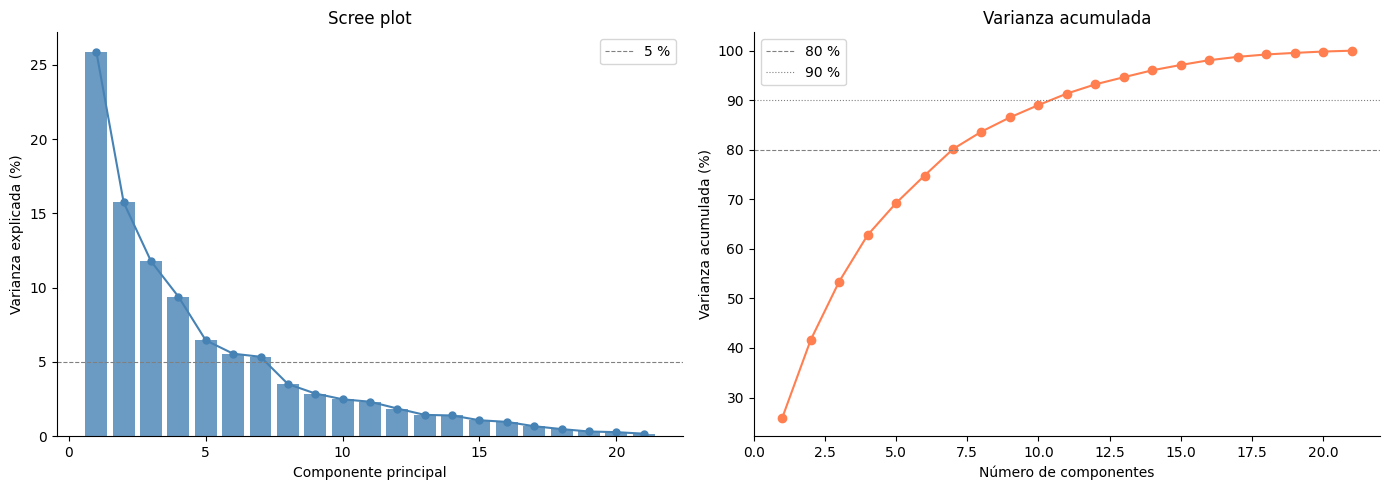

Componentes para 80 % de varianza: 7
Componentes para 90 % de varianza: 11

  PC1: 25.9 %  (acum. 25.9 %)
  PC2: 15.7 %  (acum. 41.6 %)
  PC3: 11.8 %  (acum. 53.4 %)
  PC4: 9.4 %  (acum. 62.8 %)
  PC5: 6.5 %  (acum. 69.2 %)
  PC6: 5.6 %  (acum. 74.8 %)


In [8]:
pca_full = PCA(random_state=SEED)
pca_full.fit(X)

var_exp = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(var_exp)+1), var_exp * 100, color="steelblue", alpha=0.8)
axes[0].plot(range(1, len(var_exp)+1), var_exp * 100, "o-", color="steelblue", ms=5)
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_title("Scree plot")
axes[0].axhline(5, color="gray", ls="--", lw=0.8, label="5 %")
axes[0].legend()

# Varianza acumulada
axes[1].plot(range(1, len(var_acum)+1), var_acum * 100, "o-", color="coral")
axes[1].axhline(80, color="gray", ls="--", lw=0.8, label="80 %")
axes[1].axhline(90, color="gray", ls=":", lw=0.8, label="90 %")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada (%)")
axes[1].set_title("Varianza acumulada")
axes[1].legend()

plt.tight_layout()
plt.show()

n80 = int(np.argmax(var_acum >= 0.80)) + 1
n90 = int(np.argmax(var_acum >= 0.90)) + 1
print(f"Componentes para 80 % de varianza: {n80}")
print(f"Componentes para 90 % de varianza: {n90}")
print()
for i in range(min(6, len(var_exp))):
    print(f"  PC{i+1}: {var_exp[i]*100:.1f} %  (acum. {var_acum[i]*100:.1f} %)")

### 3.2 Biplot PC1 vs PC2 — bancos coloreados por tipo de entidad

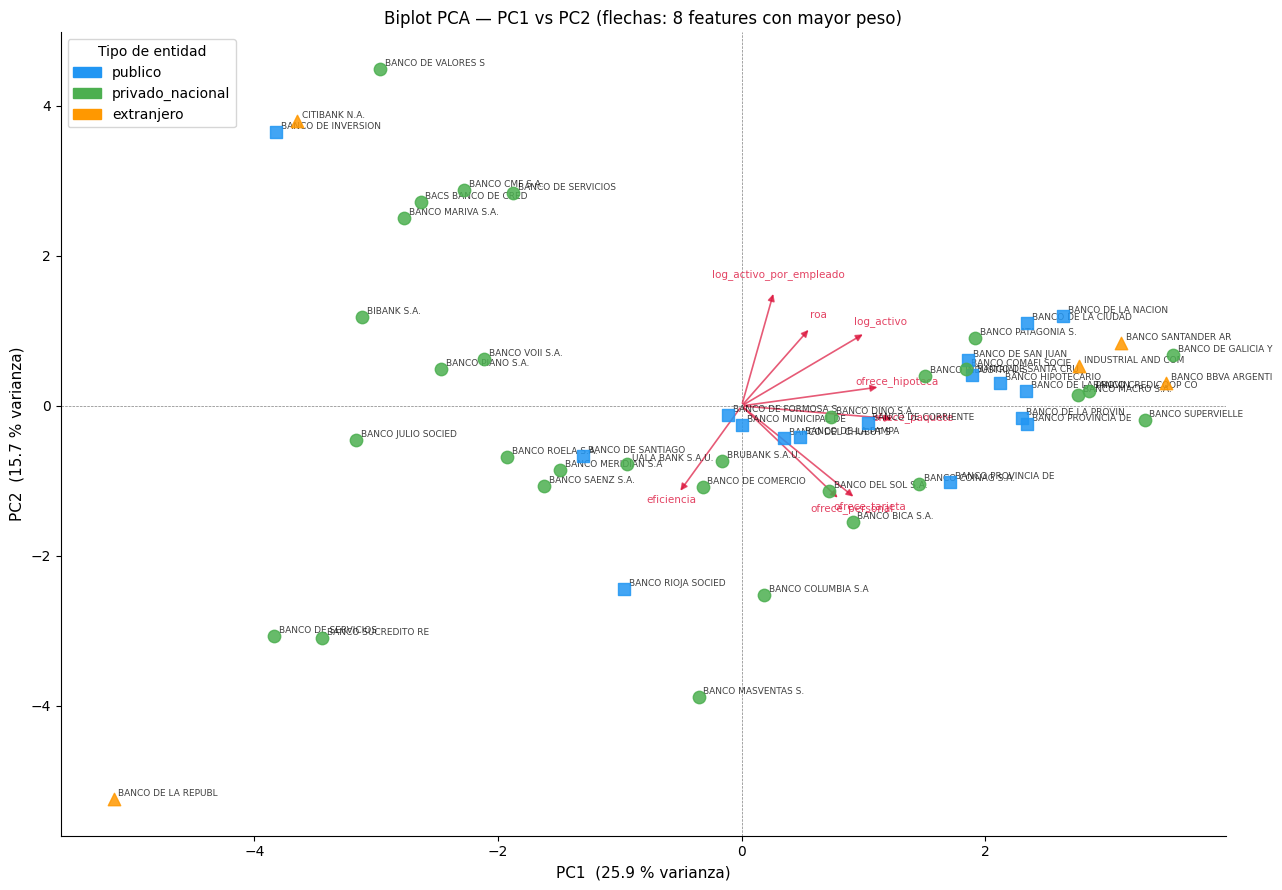

In [9]:
X_pca = pca_full.transform(X)

COLORES_TIPO = {
    "publico"         : "#2196F3",
    "privado_nacional": "#4CAF50",
    "extranjero"      : "#FF9800",
}
MARKERS_TIPO = {"publico": "s", "privado_nacional": "o", "extranjero": "^"}

fig, ax = plt.subplots(figsize=(13, 9))

for idx, row in df_imp.iterrows():
    tipo = row["tipo_entidad"]
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               c=COLORES_TIPO[tipo], marker=MARKERS_TIPO[tipo],
               s=80, alpha=0.85, zorder=5)
    nombre_corto = row["nombre_banco"][:18]
    ax.annotate(nombre_corto,
                (X_pca[idx, 0] + 0.04, X_pca[idx, 1] + 0.04),
                fontsize=6.5, alpha=0.75, zorder=4)

# Loadings arrows (solo las 8 con mayor magnitud en PC1 o PC2)
loadings = pca_full.components_[:2].T
magnitud = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
top_idx = np.argsort(magnitud)[-8:]
escala = 3.5
for j in top_idx:
    ax.annotate("", xy=(loadings[j, 0]*escala, loadings[j, 1]*escala), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color="crimson", lw=1.2, alpha=0.7))
    ax.text(loadings[j, 0]*escala*1.12, loadings[j, 1]*escala*1.12,
            FEATURES[j], fontsize=7.5, color="crimson", alpha=0.8, ha="center")

ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.set_xlabel(f"PC1  ({var_exp[0]*100:.1f} % varianza)", fontsize=11)
ax.set_ylabel(f"PC2  ({var_exp[1]*100:.1f} % varianza)", fontsize=11)
ax.set_title("Biplot PCA — PC1 vs PC2 (flechas: 8 features con mayor peso)", fontsize=12)

patches = [mpatches.Patch(color=COLORES_TIPO[t], label=t) for t in COLORES_TIPO]
ax.legend(handles=patches, title="Tipo de entidad", loc="upper left")

plt.tight_layout()
plt.show()

### 3.3 Loadings — ¿qué mide cada componente?

In [10]:
loadings_df = pd.DataFrame(
    pca_full.components_[:5].T,
    index=FEATURES,
    columns=[f"PC{i+1}" for i in range(5)]
)

print("Top 5 features por componente (valor absoluto del loading):\n")
for pc in loadings_df.columns:
    pct = var_exp[int(pc[2:])-1] * 100
    top = loadings_df[pc].abs().sort_values(ascending=False).head(5)
    print(f"  {pc}  ({pct:.1f} % varianza):")
    for feat, val in top.items():
        signo = "+" if loadings_df.loc[feat, pc] > 0 else "-"
        print(f"    {signo}{val:.3f}  {feat}")
    print()

Top 5 features por componente (valor absoluto del loading):

  PC1  (25.9 % varianza):
    +0.359  ofrece_paquete
    +0.325  ofrece_hipoteca
    +0.323  hipoteca_uva
    +0.290  log_activo
    +0.287  paquete_tiene_premium

  PC2  (15.7 % varianza):
    +0.437  log_activo_por_empleado
    -0.357  ofrece_personal
    -0.352  ofrece_tarjeta
    -0.332  eficiencia
    -0.306  cartera_irregular

  PC3  (11.8 % varianza):
    +0.527  liquidez
    +0.504  prestamos_sobre_activo
    -0.355  ofrece_pfijo
    +0.305  cartera_irregular
    -0.277  depositos_sobre_activo

  PC4  (9.4 % varianza):
    +0.508  patrimonio_sobre_activo
    +0.491  titulos_sobre_activo
    -0.369  depositos_sobre_activo
    +0.298  caja_apertura_simplificada
    +0.291  roa

  PC5  (6.5 % varianza):
    +0.470  tarjeta_tiene_premium
    -0.402  hipoteca_uva
    -0.390  ofrece_hipoteca
    -0.337  titulos_sobre_activo
    +0.283  roa



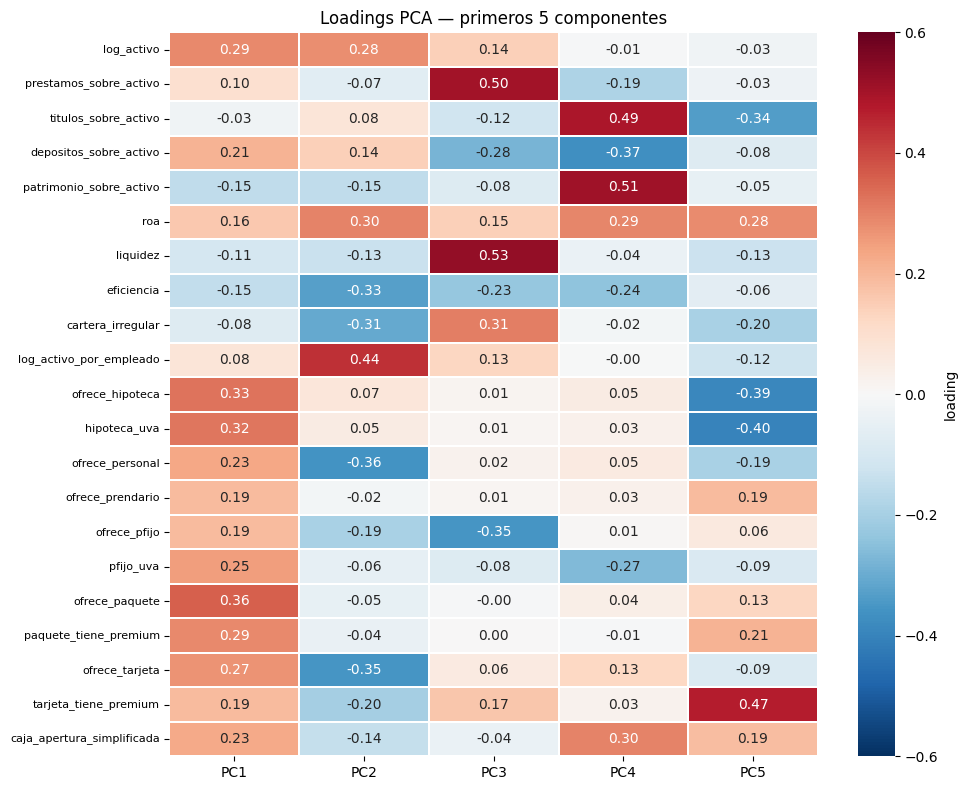

In [11]:
# Heatmap completo de loadings — primeros 5 PCs
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    loadings_df,
    cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
    annot=True, fmt=".2f", linewidths=0.3,
    ax=ax, cbar_kws={"label": "loading"}
)
ax.set_title("Loadings PCA — primeros 5 componentes", fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

### 3.4 Lectura de los componentes principales

Los loadings indican qué pesan más en cada componente. Mirando los 5 primeros:

**PC1 (25,9 % de la varianza) — Sofisticación y amplitud de la oferta minorista**
Carga positiva con `ofrece_paquete` (+0,36), `ofrece_hipoteca` (+0,32), `hipoteca_uva` (+0,32), `log_activo` (+0,29) y `paquete_tiene_premium` (+0,29). No es un eje de "tamaño puro": combina tamaño con riqueza de la oferta retail. Los bancos a la derecha del biplot son los que ofrecen el paquete completo de productos minoristas y suelen ser también los más grandes; los de la izquierda son entidades chicas con oferta acotada (típicamente un solo producto). Es la dimensión que más explica del sistema.

**PC2 (15,7 % de la varianza) — Productividad operativa vs. exposición minorista**
Eje contrapuesto: arriba `log_activo_por_empleado` (+0,44), abajo `ofrece_personal` (−0,36), `ofrece_tarjeta` (−0,35), `eficiencia` (−0,33) y `cartera_irregular` (−0,31). Separa **mayoristas eficientes con pocos empleados gestionando mucho activo** de **bancos retail-intensivos** con muchos préstamos personales y tarjetas, mayor consumo de margen por gastos administrativos y mayor mora. Esta segunda dimensión es la que más diferencia los perfiles de "calidad" del balance.

**PC3 (11,8 %) — Préstamos y liquidez vs. depósitos y plazo fijo**
Captura un eje de **fondeo y colocación**: bancos con mucha cartera de préstamos y liquidez activa frente a bancos centrados en captación de depósitos a plazo. Es la primera dimensión que separa estilos de intermediación más que sofisticación o calidad.

**Consecuencia para el clustering**
PC1 + PC2 (≈ 42 % de la varianza) son suficientes para visualizar la segmentación pero **no para reproducir el clustering**: PC3-5 aportan otro 35 %. Por eso el K-Means se corre sobre el espacio completo de 21 features estandarizadas y solo se proyecta a PCA para visualizar.

## 4. K-Means

K-Means se corre sobre el **espacio completo estandarizado** (21 features, X), no sobre los scores PCA.
Los resultados se visualizan proyectados en el plano PC1-PC2.

### 4.1 Selección de k — Elbow + Silhouette

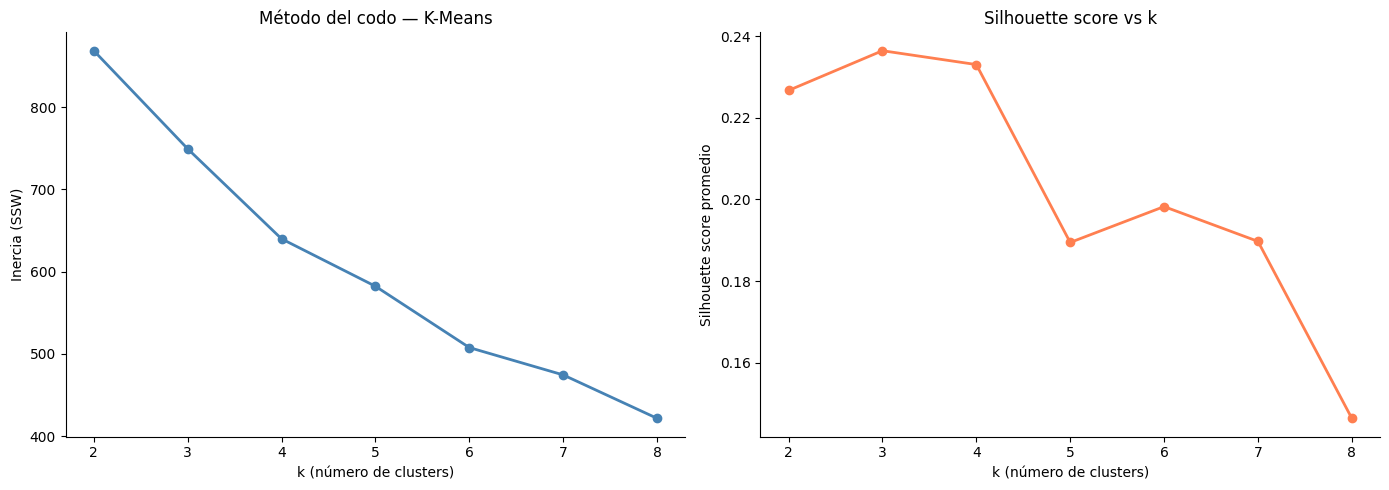

k con mayor silhouette: 3  (score = 0.236)

  k=2: silhouette = 0.227
  k=3: silhouette = 0.236  ← óptimo
  k=4: silhouette = 0.233
  k=5: silhouette = 0.189
  k=6: silhouette = 0.198
  k=7: silhouette = 0.190
  k=8: silhouette = 0.146


In [12]:
K_RANGE = range(2, 9)
inercias = []
siluetas = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=30)
    labels = km.fit_predict(X)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_RANGE, inercias, "o-", color="steelblue", lw=2)
axes[0].set_xlabel("k (número de clusters)")
axes[0].set_ylabel("Inercia (SSW)")
axes[0].set_title("Método del codo — K-Means")
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(K_RANGE, siluetas, "o-", color="coral", lw=2)
axes[1].set_xlabel("k (número de clusters)")
axes[1].set_ylabel("Silhouette score promedio")
axes[1].set_title("Silhouette score vs k")
axes[1].set_xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

k_opt = list(K_RANGE)[np.argmax(siluetas)]
print(f"k con mayor silhouette: {k_opt}  (score = {max(siluetas):.3f})")
print()
for k, sil in zip(K_RANGE, siluetas):
    marker = "  ← óptimo" if k == k_opt else ""
    print(f"  k={k}: silhouette = {sil:.3f}{marker}")

### 4.2 Ajuste del modelo final

In [13]:
# Ajustar con k elegido por silhouette (se puede sobreescribir)
K_OPTIMO = k_opt

km_final = KMeans(n_clusters=K_OPTIMO, random_state=SEED, n_init=100)
df_imp["cluster_km"] = km_final.fit_predict(X)

print(f"K-Means con k = {K_OPTIMO}")
print(f"Silhouette score : {silhouette_score(X, df_imp['cluster_km']):.3f}")
print()
print("Distribución de clusters:")
print(df_imp["cluster_km"].value_counts().sort_index().to_string())
print()
print("\nComposición por tipo de entidad:")
ct = pd.crosstab(df_imp["cluster_km"], df_imp["tipo_entidad"])
print(ct.to_string())

K-Means con k = 3
Silhouette score : 0.243

Distribución de clusters:
cluster_km
0    11
1    29
2    12


Composición por tipo de entidad:
tipo_entidad  extranjero  privado_nacional  publico
cluster_km                                         
0                      1                 9        1
1                      3                12       14
2                      1                 9        2


### 4.3 Visualización en espacio PCA

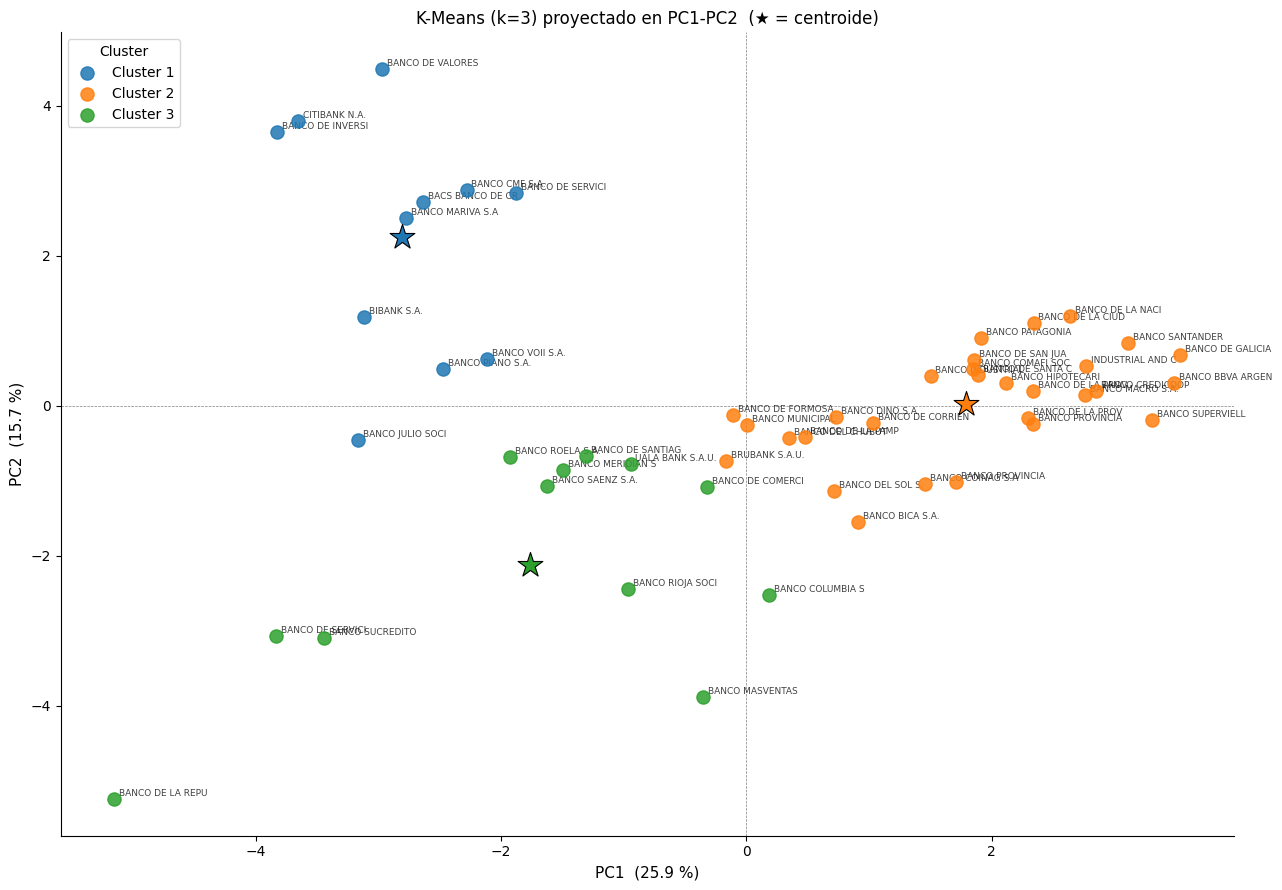

In [14]:
COLORES_KM = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(13, 9))

for cluster_id in sorted(df_imp["cluster_km"].unique()):
    mask = df_imp["cluster_km"] == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[COLORES_KM[cluster_id]], label=f"Cluster {cluster_id + 1}",
               s=90, alpha=0.85, zorder=5)

for idx, row in df_imp.iterrows():
    ax.annotate(row["nombre_banco"][:16],
                (X_pca[idx, 0] + 0.04, X_pca[idx, 1] + 0.04),
                fontsize=6.5, alpha=0.75, zorder=4)

# Centroides proyectados en PCA
centroids_pca = pca_full.transform(km_final.cluster_centers_)
for i in range(K_OPTIMO):
    ax.scatter(centroids_pca[i, 0], centroids_pca[i, 1],
               marker="*", s=350, c=[COLORES_KM[i]],
               edgecolors="black", linewidths=0.8, zorder=10)

ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.set_xlabel(f"PC1  ({var_exp[0]*100:.1f} %)", fontsize=11)
ax.set_ylabel(f"PC2  ({var_exp[1]*100:.1f} %)", fontsize=11)
ax.set_title(f"K-Means (k={K_OPTIMO}) proyectado en PC1-PC2  (★ = centroide)", fontsize=12)
ax.legend(title="Cluster", loc="upper left")

plt.tight_layout()
plt.show()

### 4.4 Perfil de clusters

In [15]:
# Mediana de las variables continuas por cluster
perfil_cont = df_imp.groupby("cluster_km")[FEATURES_CONTINUAS + ["n_productos_ofrecidos"]].median().round(3)
perfil_cont.index = [f"Cluster {i+1}" for i in perfil_cont.index]

print("Mediana por cluster — variables continuas:")
print(perfil_cont.T.to_string())

Mediana por cluster — variables continuas:
                         Cluster 1  Cluster 2  Cluster 3
log_activo                  19.666     21.325     18.339
prestamos_sobre_activo      22.200     33.164     22.068
titulos_sobre_activo         0.219      0.269      0.265
depositos_sobre_activo      54.573     67.080     46.714
patrimonio_sobre_activo      0.245      0.214      0.270
roa                          1.990      2.883     -1.376
liquidez                    20.492     20.449     25.561
eficiencia                  52.420     42.746     63.924
cartera_irregular            0.607      3.220      9.402
log_activo_por_empleado     14.738     14.135     13.411
n_productos_ofrecidos        1.000      5.000      3.000


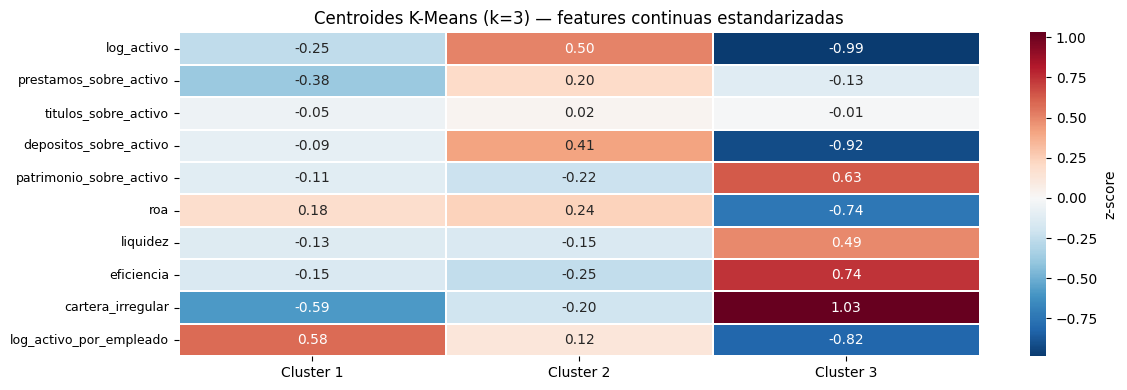

In [16]:
# Heatmap de centroides estandarizados (features continuas)
centroids_std = pd.DataFrame(
    km_final.cluster_centers_[:, :len(FEATURES_CONTINUAS)],
    columns=FEATURES_CONTINUAS,
    index=[f"Cluster {i+1}" for i in range(K_OPTIMO)]
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    centroids_std.T,
    cmap="RdBu_r", center=0,
    annot=True, fmt=".2f", linewidths=0.3,
    ax=ax, cbar_kws={"label": "z-score"}
)
ax.set_title(f"Centroides K-Means (k={K_OPTIMO}) — features continuas estandarizadas", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

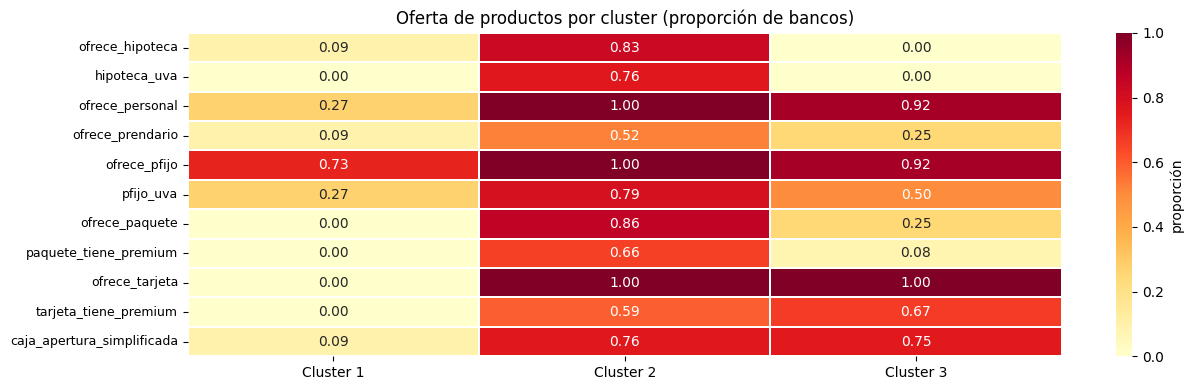

In [17]:
# Heatmap de oferta de productos por cluster (proporción de bancos que ofrecen)
perfil_bin = df_imp.groupby("cluster_km")[FEATURES_BINARIAS].mean().round(2)
perfil_bin.index = [f"Cluster {i+1}" for i in perfil_bin.index]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    perfil_bin.T,
    cmap="YlOrRd", vmin=0, vmax=1,
    annot=True, fmt=".2f", linewidths=0.3,
    ax=ax, cbar_kws={"label": "proporción"}
)
ax.set_title(f"Oferta de productos por cluster (proporción de bancos)", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [18]:
# Lista de bancos por cluster
print("Bancos por cluster:\n")
for c in sorted(df_imp["cluster_km"].unique()):
    sub = df_imp[df_imp["cluster_km"] == c].sort_values("tipo_entidad")
    print(f"{'='*60}")
    print(f"CLUSTER {c+1}  ({len(sub)} bancos)")
    print(f"{'='*60}")
    for _, row in sub.iterrows():
        print(f"  [{row['tipo_entidad'][:3].upper()}]  {row['nombre_banco']}")
    print()

Bancos por cluster:

CLUSTER 1  (11 bancos)
  [EXT]  CITIBANK N.A.
  [PRI]  BIBANK S.A.
  [PRI]  BANCO DE VALORES S.A.
  [PRI]  BANCO MARIVA S.A.
  [PRI]  BANCO PIANO S.A.
  [PRI]  BANCO JULIO SOCIEDAD ANONIMA
  [PRI]  BANCO VOII S.A.
  [PRI]  BANCO CMF S.A.
  [PRI]  BANCO DE SERVICIOS Y TRANSACCIONES
  [PRI]  BACS BANCO DE CREDITO Y SECURITIZAC
  [PUB]  BANCO DE INVERSION Y COMERCIO EXTER

CLUSTER 2  (29 bancos)
  [EXT]  INDUSTRIAL AND COMMERCIAL BANK OF C
  [EXT]  BANCO BBVA ARGENTINA S.A.
  [EXT]  BANCO SANTANDER ARGENTINA S.A.
  [PRI]  BANCO DE GALICIA Y BUENOS AIRES S.A
  [PRI]  BANCO BICA S.A.
  [PRI]  BANCO INDUSTRIAL S.A.
  [PRI]  BANCO DEL SOL S.A.
  [PRI]  BANCO COMAFI SOCIEDAD ANONIMA
  [PRI]  BANCO MACRO S.A.
  [PRI]  BANCO CREDICOOP COOPERATIVO LIMITAD
  [PRI]  BRUBANK S.A.U.
  [PRI]  BANCO COINAG S.A.
  [PRI]  BANCO DINO S.A.
  [PRI]  BANCO PATAGONIA S.A.
  [PRI]  BANCO SUPERVIELLE S.A.
  [PUB]  BANCO DEL CHUBUT S.A.
  [PUB]  BANCO DE SAN JUAN S.A.
  [PUB]  BANCO DE LA PA

### 4.5 K=4 comparativo

El silhouette es bastante parejo entre k=3 (0,236) y k=4 (0,233): la diferencia es muy chica, así que vale la pena ver qué cluster se divide cuando aumentamos a 4. Si emerge un perfil interpretable que estaba dentro de uno de los grupos de k=3, k=4 puede ser una segmentación más útil para la tesis.

In [19]:
km_k4 = KMeans(n_clusters=4, random_state=SEED, n_init=100)
df_imp["cluster_km_k4"] = km_k4.fit_predict(X)

print(f"K-Means con k = 4")
print(f"Silhouette score : {silhouette_score(X, df_imp['cluster_km_k4']):.3f}")
print()
print("Distribución de clusters:")
print(df_imp["cluster_km_k4"].value_counts().sort_index().to_string())
print()
print("\nComposición por tipo de entidad:")
ct_k4 = pd.crosstab(df_imp["cluster_km_k4"], df_imp["tipo_entidad"])
print(ct_k4.to_string())

K-Means con k = 4
Silhouette score : 0.204

Distribución de clusters:
cluster_km_k4
0     8
1    23
2    20
3     1


Composición por tipo de entidad:
tipo_entidad   extranjero  privado_nacional  publico
cluster_km_k4                                       
0                       1                 6        1
1                       3                 9       11
2                       1                14        5
3                       0                 1        0


In [20]:
# Mediana por cluster — k=4
perfil_k4 = df_imp.groupby("cluster_km_k4")[FEATURES_CONTINUAS + ["n_productos_ofrecidos"]].median().T
perfil_k4.columns = [f"Cluster {i+1}" for i in perfil_k4.columns]
print("Mediana por cluster — k=4:")
perfil_k4.round(3)

Mediana por cluster — k=4:


,Cluster 1,Cluster 2,Cluster 3,Cluster 4
log_activo,20.046,22.011,18.825,18.897
prestamos_sobre_activo,24.399,31.771,22.591,82.510
titulos_sobre_activo,0.218,0.269,0.268,0.264
depositos_sobre_activo,46.932,67.080,62.369,0.251
patrimonio_sobre_activo,0.251,0.200,0.252,0.184
roa,2.028,3.260,0.611,-4.476
liquidez,23.532,20.449,22.296,1621.766
eficiencia,36.068,38.175,63.924,57.939
cartera_irregular,0.555,3.207,4.177,20.487
log_activo_por_empleado,14.853,14.224,13.354,13.714


In [21]:
# Tabla de contingencia k=3 vs k=4: ¿qué cluster del k=3 se subdivide?
ct_k3_vs_k4 = pd.crosstab(
    df_imp["cluster_km"].map(lambda x: f"k3-C{x+1}"),
    df_imp["cluster_km_k4"].map(lambda x: f"k4-C{x+1}"),
)
print("Tabla de contingencia: K-Means k=3 vs k=4")
print()
print(ct_k3_vs_k4.to_string())

Tabla de contingencia: K-Means k=3 vs k=4

cluster_km_k4  k4-C1  k4-C2  k4-C3  k4-C4
cluster_km                               
k3-C1              8      0      3      0
k3-C2              0     23      6      0
k3-C3              0      0     11      1


In [22]:
# Bancos por cluster en k=4
print("Bancos por cluster (k=4):\n")
for c in sorted(df_imp["cluster_km_k4"].unique()):
    sub = df_imp[df_imp["cluster_km_k4"] == c].sort_values("nombre_banco")
    print(f"{'='*60}")
    print(f"CLUSTER {c+1}  ({len(sub)} bancos)")
    print(f"{'='*60}")
    for _, row in sub.iterrows():
        tag = {"publico": "[PUB]", "privado_nacional": "[PRI]", "extranjero": "[EXT]"}[row["tipo_entidad"]]
        print(f"  {tag}  {row['nombre_banco'][:38]}")
    print()

Bancos por cluster (k=4):

CLUSTER 1  (8 bancos)
  [PRI]  BACS BANCO DE CREDITO Y SECURITIZAC
  [PRI]  BANCO CMF S.A.
  [PUB]  BANCO DE INVERSION Y COMERCIO EXTER
  [PRI]  BANCO DE SERVICIOS Y TRANSACCIONES
  [PRI]  BANCO DE VALORES S.A.
  [PRI]  BANCO MARIVA S.A.
  [PRI]  BIBANK S.A.
  [EXT]  CITIBANK N.A.

CLUSTER 2  (23 bancos)
  [EXT]  BANCO BBVA ARGENTINA S.A.
  [PRI]  BANCO COINAG S.A.
  [PRI]  BANCO COMAFI SOCIEDAD ANONIMA
  [PRI]  BANCO CREDICOOP COOPERATIVO LIMITAD
  [PUB]  BANCO DE CORRIENTES S.A.
  [PRI]  BANCO DE GALICIA Y BUENOS AIRES S.A
  [PUB]  BANCO DE LA CIUDAD DE BUENOS AIRES
  [PUB]  BANCO DE LA NACION ARGENTINA
  [PUB]  BANCO DE LA PAMPA SA
  [PUB]  BANCO DE LA PROVINCIA DE BUENOS AIR
  [PUB]  BANCO DE LA PROVINCIA DE CORDOBA S.
  [PUB]  BANCO DE SAN JUAN S.A.
  [PUB]  BANCO DE SANTA CRUZ S.A.
  [PRI]  BANCO DINO S.A.
  [PUB]  BANCO HIPOTECARIO S.A.
  [PRI]  BANCO INDUSTRIAL S.A.
  [PRI]  BANCO MACRO S.A.
  [PRI]  BANCO PATAGONIA S.A.
  [PUB]  BANCO PROVINCIA DE TI

**Lectura:** la tabla de contingencia entre k=3 y k=4 muestra cuál de los tres clusters originales se subdivide al pasar a 4. Si el cluster que se parte es el más grande (Cluster 2, banca universal grande, 29 bancos) la separación probablemente refleje diferencias entre **bancos públicos provinciales** y **privados nacionales grandes**, que en k=3 quedan juntos por su tamaño y su oferta amplia pero tienen modelos de negocio distintos (mandato político-territorial vs. competencia comercial).

### 4.6 K=3 sin el outlier (Banco de Servicios Financieros)

El análisis con k=4 reveló que Banco de Servicios Financieros tiene un perfil tan atípico (liquidez 1.621 %, depósitos casi nulos, financiación 100 % con capital propio) que distorsiona las métricas globales. En esta subsección rehacemos K-Means k=3 excluyéndolo, para ver cuánto cambia la segmentación y si las métricas mejoran.

Es una **prueba de robustez**: si los clusters son estables con o sin el outlier, eso refuerza la confianza en la partición. Si cambian mucho, hay que reportar las dos versiones.

In [23]:
# Identificamos el outlier por nombre y lo excluimos
OUTLIER_NOMBRE = "BANCO DE SERVICIOS FINANCIEROS"
mask_no_outlier = ~df_imp["nombre_banco"].str.contains(OUTLIER_NOMBRE, case=False, na=False)
df_no_out = df_imp[mask_no_outlier].copy().reset_index(drop=True)

# Recalculamos X sin el outlier (con el mismo scaler que el resto del notebook
# para mantener comparabilidad).
X_no_out = scaler.transform(df_no_out[FEATURES])

print(f"Bancos en el clustering original : {len(df_imp)}")
print(f"Bancos sin outlier               : {len(df_no_out)}")
print(f"Excluido                         : {df_imp.loc[~mask_no_outlier, 'nombre_banco'].iloc[0]}")

Bancos en el clustering original : 52
Bancos sin outlier               : 51
Excluido                         : BANCO DE SERVICIOS FINANCIEROS S.A.


In [24]:
# K-Means k=3 sin el outlier
km_no_out = KMeans(n_clusters=3, random_state=SEED, n_init=100)
df_no_out["cluster_km_no_out"] = km_no_out.fit_predict(X_no_out)

sil_no_out = silhouette_score(X_no_out, df_no_out["cluster_km_no_out"])
print(f"K-Means k=3 sin outlier")
print(f"Silhouette score : {sil_no_out:.3f}  (vs {silhouette_score(X, df_imp['cluster_km']):.3f} con outlier)")
print()
print("Distribución de clusters:")
print(df_no_out["cluster_km_no_out"].value_counts().sort_index().to_string())
print()
print("\nComposición por tipo de entidad:")
ct_no = pd.crosstab(df_no_out["cluster_km_no_out"], df_no_out["tipo_entidad"])
print(ct_no.to_string())

K-Means k=3 sin outlier
Silhouette score : 0.208  (vs 0.243 con outlier)

Distribución de clusters:
cluster_km_no_out
0    23
1    20
2     8


Composición por tipo de entidad:
tipo_entidad       extranjero  privado_nacional  publico
cluster_km_no_out                                       
0                           3                 9       11
1                           1                14        5
2                           1                 6        1


In [25]:
# Mediana por cluster — k=3 sin outlier
perfil_no_out = df_no_out.groupby("cluster_km_no_out")[FEATURES_CONTINUAS + ["n_productos_ofrecidos"]].median().T
perfil_no_out.columns = [f"Cluster {i+1}" for i in perfil_no_out.columns]
print("Mediana por cluster — k=3 sin outlier:")
perfil_no_out.round(3)

Mediana por cluster — k=3 sin outlier:


,Cluster 1,Cluster 2,Cluster 3
log_activo,22.011,18.825,20.046
prestamos_sobre_activo,31.771,22.591,24.399
titulos_sobre_activo,0.269,0.268,0.218
depositos_sobre_activo,67.080,62.369,46.932
patrimonio_sobre_activo,0.200,0.252,0.251
roa,3.260,0.611,2.028
liquidez,20.449,22.296,23.532
eficiencia,38.175,63.924,36.068
cartera_irregular,3.207,4.177,0.555
log_activo_por_empleado,14.224,13.354,14.853


In [26]:
# Tabla de contingencia: k=3 con outlier vs k=3 sin outlier (sobre los 51 bancos comunes)
df_comparable = df_imp[mask_no_outlier].copy().reset_index(drop=True)
df_comparable["cluster_km_no_out"] = df_no_out["cluster_km_no_out"].values

ct_comp = pd.crosstab(
    df_comparable["cluster_km"].map(lambda x: f"CON-C{x+1}"),
    df_comparable["cluster_km_no_out"].map(lambda x: f"SIN-C{x+1}"),
)
print("Tabla de contingencia: K-Means k=3 con outlier vs sin outlier")
print(ct_comp.to_string())
print()

from sklearn.metrics import adjusted_rand_score
ari_robust = adjusted_rand_score(
    df_comparable["cluster_km"], df_comparable["cluster_km_no_out"]
)
print(f"\nAdjusted Rand Index : {ari_robust:.3f}")
print("(ARI cerca de 1 = clusters esencialmente iguales; <0.7 = la partición cambió)")

Tabla de contingencia: K-Means k=3 con outlier vs sin outlier
cluster_km_no_out  SIN-C1  SIN-C2  SIN-C3
cluster_km                               
CON-C1                  0       3       8
CON-C2                 23       6       0
CON-C3                  0      11       0


Adjusted Rand Index : 0.539
(ARI cerca de 1 = clusters esencialmente iguales; <0.7 = la partición cambió)


**Lectura:**

- **Si el silhouette sube y el ARI con outlier está alto (>0,8)**, los clusters son robustos y conviene reportar el K-Means k=3 sin el outlier como modelo final, mencionando al outlier en la discusión.
- **Si el silhouette sube y el ARI baja (<0,7)**, sacar el outlier cambió la partición — hay que reportar las dos versiones y discutir cuál tiene mejor interpretación de negocio.
- **Si el silhouette no sube apreciablemente**, el outlier no era el principal factor que penalizaba la métrica y conviene mantener el modelo original con los 52 bancos.

## 5. Cluster jerárquico (Ward)

Como tercer método aplicamos clustering aglomerativo con linkage de **Ward** sobre el mismo espacio de 21 features estandarizadas. Ward minimiza la suma de cuadrados intra-cluster en cada fusión y produce particiones de tamaño parecido — eso lo hace directamente comparable con K-Means.

El jerárquico aporta dos cosas que K-Means y DBSCAN no dan:
1. **Dendrograma**: vista global de la estructura de fusiones. Permite ver visualmente si hay un k "natural" o si las distancias entre fusiones crecen suavemente (que es lo que esperamos si el sistema es un continuo).
2. **Múltiples cortes desde un único árbol**: una vez ajustado, k=2, k=3, k=4 son cortes a alturas distintas del mismo modelo, lo que facilita la comparación.

### 5.1 Dendrograma y coeficiente cofenético

In [27]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram, cophenet
from scipy.spatial.distance import pdist

# Linkage de Ward sobre el espacio estandarizado (mismo X del K-Means)
Z = linkage(X, method="ward")

# Coeficiente cofenético: correlación entre distancias originales y las
# implícitas en el dendrograma. Cerca de 1 = el árbol refleja bien la
# estructura. Valores 0.6-0.8 son razonables; <0.5 indica que el linkage
# no captura bien las distancias.
dist_pairs = pdist(X)
coph_corr, _ = cophenet(Z, dist_pairs)
print(f"Coeficiente cofenético: {coph_corr:.3f}")

Coeficiente cofenético: 0.457


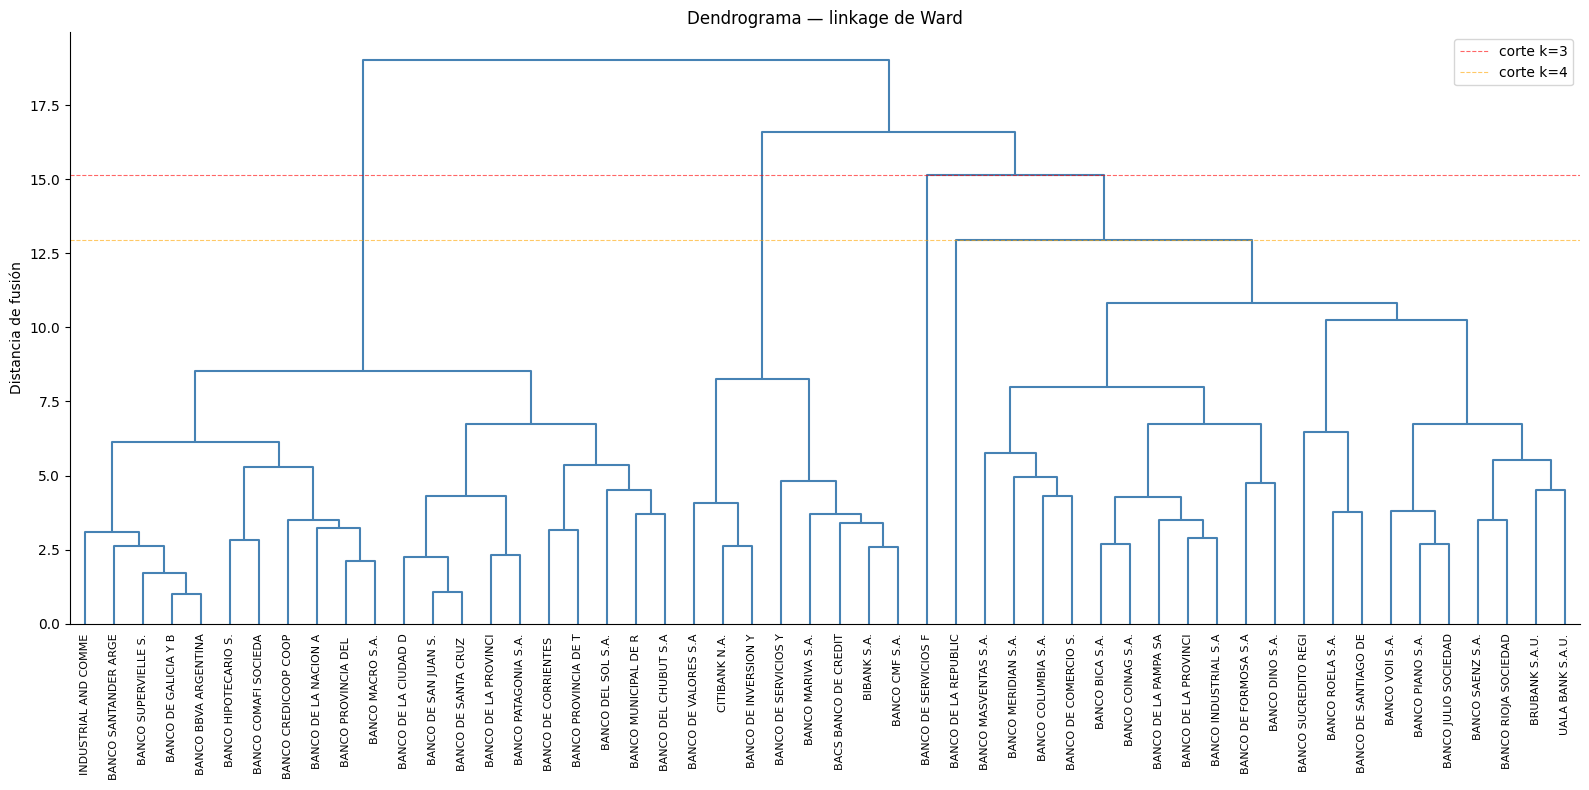

In [28]:
# Dendrograma completo, con etiquetas de banco recortadas
fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(
    Z,
    labels=df_imp["nombre_banco"].str[:20].values,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0,        # un único color, no queremos sugerir corte aún
    above_threshold_color="steelblue",
    ax=ax,
)
ax.set_title("Dendrograma — linkage de Ward")
ax.set_ylabel("Distancia de fusión")
ax.axhline(y=Z[-3, 2], color="red", ls="--", lw=0.8, alpha=0.6, label="corte k=3")
ax.axhline(y=Z[-4, 2], color="orange", ls="--", lw=0.8, alpha=0.6, label="corte k=4")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Lectura del dendrograma**: las líneas punteadas indican la altura a la que hay que cortar el árbol para obtener 3 y 4 clusters. La distancia entre fusiones — el largo vertical entre divisiones — indica cuán distintos son los grupos que se unen. Si todas las fusiones tienen alturas parecidas el sistema se parece a un continuo; si hay un salto grande seguido de varias fusiones cortas, ese salto sugiere un k "natural".

### 5.2 Cortes a k=3 y k=4 + métricas

In [29]:
# Cortes del dendrograma
df_imp["cluster_jer_k3"] = fcluster(Z, t=3, criterion="maxclust") - 1
df_imp["cluster_jer_k4"] = fcluster(Z, t=4, criterion="maxclust") - 1

print(f"Silhouette jerárquico k=3 : {silhouette_score(X, df_imp['cluster_jer_k3']):.3f}")
print(f"Silhouette jerárquico k=4 : {silhouette_score(X, df_imp['cluster_jer_k4']):.3f}")
print()

print("Distribución k=3:")
print(df_imp["cluster_jer_k3"].value_counts().sort_index().to_string())
print()
print("Distribución k=4:")
print(df_imp["cluster_jer_k4"].value_counts().sort_index().to_string())

Silhouette jerárquico k=3 : 0.175


Silhouette jerárquico k=4 : 0.179

Distribución k=3:
cluster_jer_k3
0    21
1     8
2    23

Distribución k=4:
cluster_jer_k4
0    21
1     8
2    22
3     1


### 5.3 Comparación con K-Means

In [30]:
# K-Means k=3 vs Jerárquico k=3
ct_km_jer_k3 = pd.crosstab(
    df_imp["cluster_km"].map(lambda x: f"KM-{x+1}"),
    df_imp["cluster_jer_k3"].map(lambda x: f"JER-{x+1}"),
)
print("K-Means k=3 vs Jerárquico k=3")
print(ct_km_jer_k3.to_string())
print()

# Adjusted Rand Index — métrica de acuerdo entre particiones (1 = idénticas, 0 = azar)
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari_k3 = adjusted_rand_score(df_imp["cluster_km"], df_imp["cluster_jer_k3"])
nmi_k3 = normalized_mutual_info_score(df_imp["cluster_km"], df_imp["cluster_jer_k3"])
print(f"\nAdjusted Rand Index (k=3)        : {ari_k3:.3f}")
print(f"Normalized Mutual Information (k=3): {nmi_k3:.3f}")

K-Means k=3 vs Jerárquico k=3
cluster_jer_k3  JER-1  JER-2  JER-3
cluster_km                         
KM-1                0      8      3
KM-2               21      0      8
KM-3                0      0     12




Adjusted Rand Index (k=3)        : 0.446
Normalized Mutual Information (k=3): 0.560


In [31]:
# K-Means k=4 vs Jerárquico k=4
ct_km_jer_k4 = pd.crosstab(
    df_imp["cluster_km_k4"].map(lambda x: f"KM-{x+1}"),
    df_imp["cluster_jer_k4"].map(lambda x: f"JER-{x+1}"),
)
print("K-Means k=4 vs Jerárquico k=4")
print(ct_km_jer_k4.to_string())
print()
ari_k4 = adjusted_rand_score(df_imp["cluster_km_k4"], df_imp["cluster_jer_k4"])
nmi_k4 = normalized_mutual_info_score(df_imp["cluster_km_k4"], df_imp["cluster_jer_k4"])
print(f"\nAdjusted Rand Index (k=4)        : {ari_k4:.3f}")
print(f"Normalized Mutual Information (k=4): {nmi_k4:.3f}")

K-Means k=4 vs Jerárquico k=4


cluster_jer_k4  JER-1  JER-2  JER-3  JER-4
cluster_km_k4                             
KM-1                0      8      0      0
KM-2               18      0      5      0
KM-3                3      0     17      0
KM-4                0      0      0      1


Adjusted Rand Index (k=4)        : 0.539
Normalized Mutual Information (k=4): 0.640


**Lectura:** ARI > 0,5 indica acuerdo sustancial entre K-Means y jerárquico; > 0,7 acuerdo muy fuerte. Si los dos métodos coinciden mayoritariamente, refuerza que la segmentación es robusta y no un artefacto del algoritmo. Si el acuerdo es bajo, hay que decidir cuál de las dos particiones tiene mejor interpretación de negocio.

### 5.4 Perfil de los clusters jerárquicos (k=3)

In [32]:
perfil_jer = df_imp.groupby("cluster_jer_k3")[FEATURES_CONTINUAS + ["n_productos_ofrecidos"]].median().T
perfil_jer.columns = [f"Cluster {i+1}" for i in perfil_jer.columns]
print("Mediana por cluster — jerárquico k=3:")
perfil_jer.round(3)

Mediana por cluster — jerárquico k=3:


,Cluster 1,Cluster 2,Cluster 3
log_activo,22.011,20.046,18.897
prestamos_sobre_activo,35.272,24.399,22.263
titulos_sobre_activo,0.269,0.218,0.266
depositos_sobre_activo,66.488,46.932,61.763
patrimonio_sobre_activo,0.215,0.251,0.243
roa,3.260,2.028,0.863
liquidez,20.449,23.532,24.100
eficiencia,38.942,36.068,57.939
cartera_irregular,3.207,0.555,4.123
log_activo_por_empleado,14.224,14.853,13.657


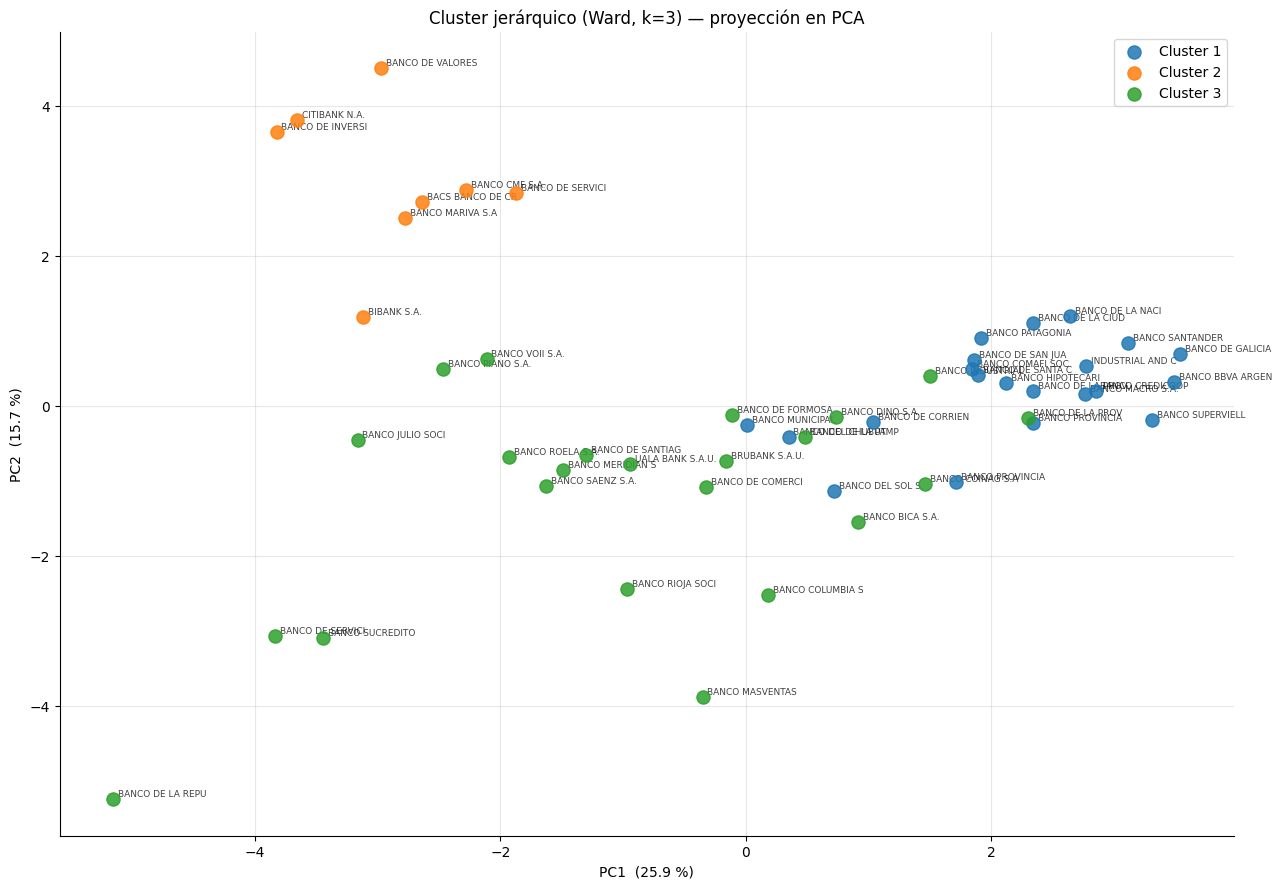

In [33]:
# Visualización en espacio PCA — jerárquico k=3
fig, ax = plt.subplots(figsize=(13, 9))
for cluster_id in sorted(df_imp["cluster_jer_k3"].unique()):
    mask = df_imp["cluster_jer_k3"] == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[COLORES_KM[cluster_id]], label=f"Cluster {cluster_id + 1}",
               s=90, alpha=0.85, zorder=5)

for idx, row in df_imp.iterrows():
    ax.annotate(row["nombre_banco"][:16],
                (X_pca[idx, 0] + 0.04, X_pca[idx, 1] + 0.04),
                fontsize=6.5, alpha=0.75, zorder=4)

ax.set_xlabel(f"PC1  ({var_exp[0]*100:.1f} %)")
ax.set_ylabel(f"PC2  ({var_exp[1]*100:.1f} %)")
ax.set_title("Cluster jerárquico (Ward, k=3) — proyección en PCA")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. DBSCAN

DBSCAN se aplica sobre el **espacio PCA reducido** (primeros `n80` componentes).
Esto mitiga la maldición de la dimensionalidad: las distancias euclídeas son más
informativas en pocas dimensiones que en 21.

**Ventaja de DBSCAN sobre K-Means:** detecta clusters de forma arbitraria y marca
outliers explícitamente (etiqueta -1), lo que es útil para identificar bancos con
perfil atípico.

### 6.1 Espacio reducido para DBSCAN

In [34]:
# Usar los componentes que explican ≥ 80 % de varianza
N_COMP_DBSCAN = n80
X_red = X_pca[:, :N_COMP_DBSCAN]

print(f"Dimensiones para DBSCAN: {X_red.shape}  ({N_COMP_DBSCAN} PCs, {var_acum[N_COMP_DBSCAN-1]*100:.1f}% varianza)")

Dimensiones para DBSCAN: (52, 7)  (7 PCs, 80.2% varianza)


### 6.2 Calibración de eps — gráfico de distancias k-NN

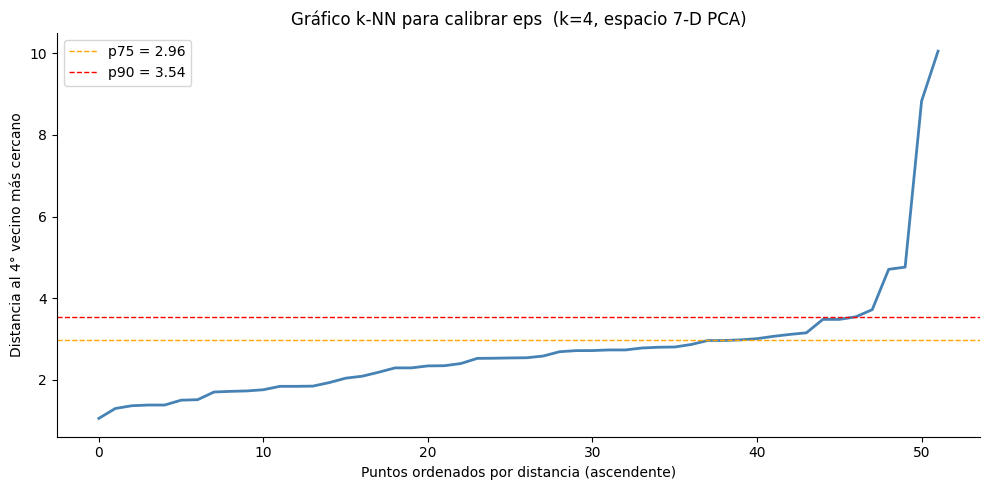

Percentiles de la distribución de distancias:
  p50: 2.536
  p60: 2.724
  p70: 2.845
  p75: 2.965
  p80: 3.052
  p85: 3.265
  p90: 3.535
  p95: 4.730


In [35]:
# El gráfico de distancias k-NN ayuda a elegir eps:
# eps = valor donde la curva hace "codo" (pasa de crecer lento a crecer rápido)
K_KNN = 4  # min_samples tentativo

knn = NearestNeighbors(n_neighbors=K_KNN)
knn.fit(X_red)
dists, _ = knn.kneighbors(X_red)
dists_k = np.sort(dists[:, -1])  # distancia al k-ésimo vecino, ordenada

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dists_k, color="steelblue", lw=2)
ax.set_xlabel("Puntos ordenados por distancia (ascendente)")
ax.set_ylabel(f"Distancia al {K_KNN}° vecino más cercano")
ax.set_title(f"Gráfico k-NN para calibrar eps  (k={K_KNN}, espacio {N_COMP_DBSCAN}-D PCA)")

# Percentiles de referencia
for p, col in [(75, "orange"), (90, "red")]:
    val = np.percentile(dists_k, p)
    ax.axhline(val, color=col, ls="--", lw=1, label=f"p{p} = {val:.2f}")

ax.legend()
plt.tight_layout()
plt.show()

print("Percentiles de la distribución de distancias:")
for p in [50, 60, 70, 75, 80, 85, 90, 95]:
    print(f"  p{p}: {np.percentile(dists_k, p):.3f}")

### 6.3 Ajuste de DBSCAN

Ajustar `EPS` y `MIN_SAMPLES` según el gráfico anterior.
Regla práctica: elegir eps en el "codo" de la curva k-NN.

In [36]:
# Ajustar según el gráfico de k-NN
# EPS = float(np.percentile(dists_k, 80))   # punto de inflexión orientativo
EPS = 1.5
MIN_SAMPLES = 3

db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
df_imp["cluster_db"] = db.fit_predict(X_red)

n_clusters_db = len(set(df_imp["cluster_db"])) - (1 if -1 in df_imp["cluster_db"].values else 0)
n_ruido = (df_imp["cluster_db"] == -1).sum()

print(f"DBSCAN: eps={EPS:.3f}, min_samples={MIN_SAMPLES}")
print(f"Clusters encontrados : {n_clusters_db}")
print(f"Puntos de ruido      : {n_ruido} ({n_ruido/len(df_imp)*100:.1f} %)")
print()
print("Distribución:")
print(df_imp["cluster_db"].value_counts().sort_index().to_string())

DBSCAN: eps=1.500, min_samples=3
Clusters encontrados : 2
Puntos de ruido      : 44 (84.6 %)

Distribución:
cluster_db
-1    44
 0     4
 1     4


### 6.4 Visualización en espacio PCA

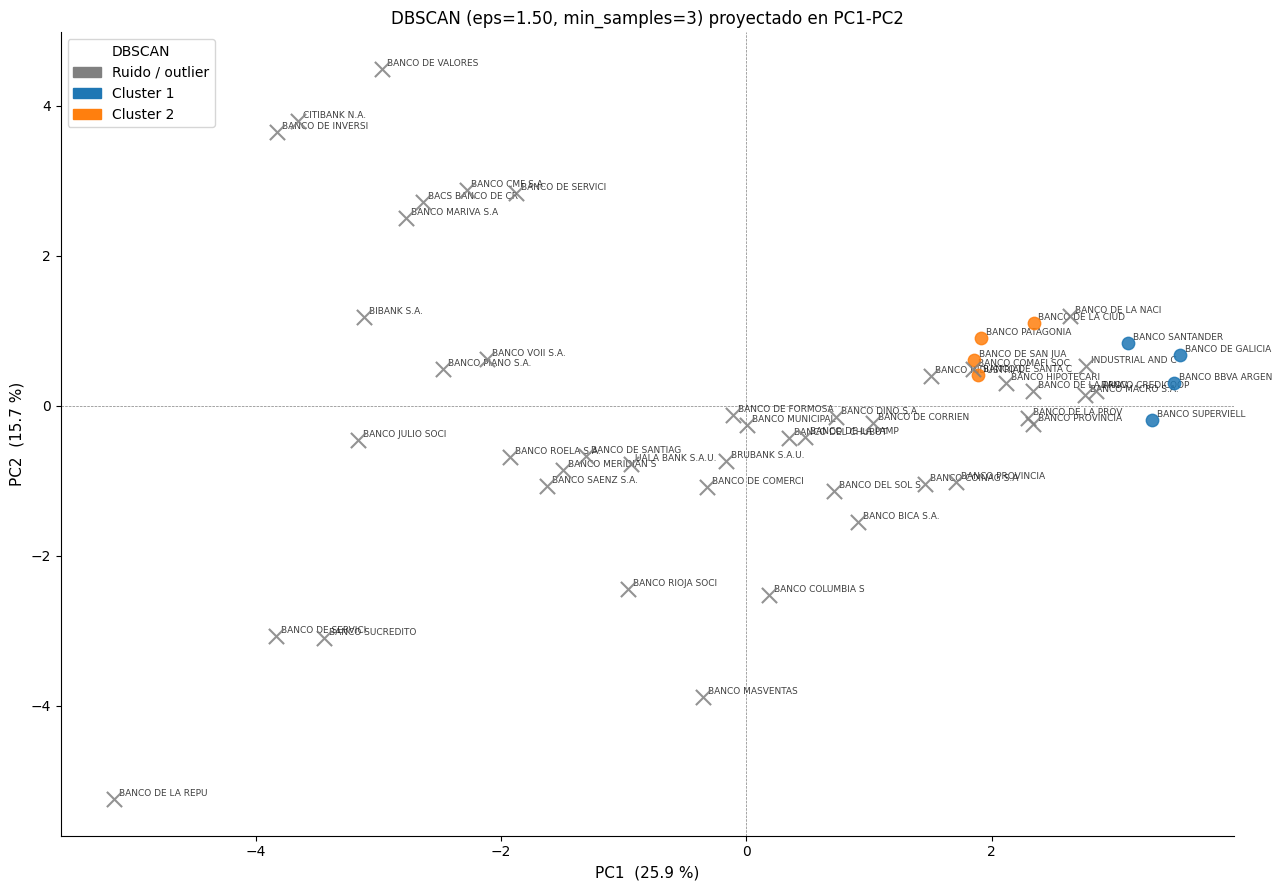


Bancos marcados como ruido/outliers:
                       nombre_banco     tipo_entidad
       BANCO DE LA NACION ARGENTINA          publico
BANCO DE LA PROVINCIA DE BUENOS AIR          publico
INDUSTRIAL AND COMMERCIAL BANK OF C       extranjero
                      CITIBANK N.A.       extranjero
BANCO DE LA PROVINCIA DE CORDOBA S.          publico
             BANCO HIPOTECARIO S.A.          publico
         BANCO MUNICIPAL DE ROSARIO          publico
              BANCO DEL CHUBUT S.A.          publico
               BANCO DE LA PAMPA SA          publico
           BANCO DE CORRIENTES S.A.          publico
BANCO PROVINCIA DEL NEUQUÉN SOCIEDA          publico
                     BRUBANK S.A.U. privado_nacional
                        BIBANK S.A. privado_nacional
BANCO CREDICOOP COOPERATIVO LIMITAD privado_nacional
              BANCO DE VALORES S.A. privado_nacional
                   BANCO ROELA S.A. privado_nacional
                  BANCO MARIVA S.A. privado_nacional
BANCO PR

In [37]:
unique_labels_db = sorted(df_imp["cluster_db"].unique())
palette_db = {}
color_idx = 0
for lab in unique_labels_db:
    if lab == -1:
        palette_db[lab] = ("gray", "x", 120, "Ruido / outlier")
    else:
        palette_db[lab] = (plt.cm.tab10.colors[color_idx], "o", 80, f"Cluster {lab+1}")
        color_idx += 1

fig, ax = plt.subplots(figsize=(13, 9))

for idx, row in df_imp.iterrows():
    lab = row["cluster_db"]
    color, marker, size, _ = palette_db[lab]
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               c=[color], marker=marker, s=size, alpha=0.85, zorder=5)
    ax.annotate(row["nombre_banco"][:16],
                (X_pca[idx, 0] + 0.04, X_pca[idx, 1] + 0.04),
                fontsize=6.5, alpha=0.75, zorder=4)

patches_db = [mpatches.Patch(color=v[0], label=v[3]) for v in palette_db.values()]
ax.legend(handles=patches_db, title="DBSCAN", loc="upper left")

ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.set_xlabel(f"PC1  ({var_exp[0]*100:.1f} %)", fontsize=11)
ax.set_ylabel(f"PC2  ({var_exp[1]*100:.1f} %)", fontsize=11)
ax.set_title(f"DBSCAN (eps={EPS:.2f}, min_samples={MIN_SAMPLES}) proyectado en PC1-PC2", fontsize=12)

plt.tight_layout()
plt.show()

print("\nBancos marcados como ruido/outliers:")
outliers = df_imp[df_imp["cluster_db"] == -1][["nombre_banco", "tipo_entidad"]]
print(outliers.to_string(index=False) if len(outliers) > 0 else "  Ninguno")

### 6.5 Comparación K-Means vs DBSCAN

In [38]:
print("Tabla de contingencia: K-Means vs DBSCAN\n")
ct2 = pd.crosstab(
    df_imp["cluster_km"].map(lambda x: f"KM-{x+1}"),
    df_imp["cluster_db"].map(lambda x: f"DB-{x+1}" if x >= 0 else "Ruido"),
    rownames=["K-Means"], colnames=["DBSCAN"]
)
print(ct2.to_string())
print()

# Bancos con clasificación discordante entre algoritmos
# Para cada cluster de K-Means, la etiqueta DBSCAN más frecuente
mode_per_km = df_imp.groupby("cluster_km")["cluster_db"].agg(lambda x: x.mode().iloc[0])
df_imp["db_esperado"] = df_imp["cluster_km"].map(mode_per_km)
df_imp["coincide"] = df_imp["cluster_db"] == df_imp["db_esperado"]

discordantes = df_imp[~df_imp["coincide"]][["nombre_banco", "tipo_entidad", "cluster_km", "cluster_db"]].copy()
discordantes["cluster_km"] = discordantes["cluster_km"] + 1
print(f"Bancos con clasificación discordante entre algoritmos: {len(discordantes)}")
if len(discordantes) > 0:
    print(discordantes.to_string(index=False))

Tabla de contingencia: K-Means vs DBSCAN

DBSCAN   DB-1  DB-2  Ruido
K-Means                   
KM-1        0     0     11
KM-2        4     4     21
KM-3        0     0     12

Bancos con clasificación discordante entre algoritmos: 8
                       nombre_banco     tipo_entidad  cluster_km  cluster_db
BANCO DE GALICIA Y BUENOS AIRES S.A privado_nacional           2           0
          BANCO BBVA ARGENTINA S.A.       extranjero           2           0
             BANCO SUPERVIELLE S.A. privado_nacional           2           0
 BANCO DE LA CIUDAD DE BUENOS AIRES          publico           2           1
               BANCO PATAGONIA S.A. privado_nacional           2           1
             BANCO DE SAN JUAN S.A.          publico           2           1
     BANCO SANTANDER ARGENTINA S.A.       extranjero           2           0
           BANCO DE SANTA CRUZ S.A.          publico           2           1


## 7. Interpretación y conclusiones

In [39]:
# Tabla resumen comparativa por cluster K-Means
VARS_RESUMEN = {
    "log_activo"            : "Tamaño (log activo)",
    "roa"                   : "ROA (%)",
    "cartera_irregular"     : "Cartera irregular (%)",
    "liquidez"              : "Liquidez (%)",
    "eficiencia"            : "Eficiencia (%)",
    "prestamos_sobre_activo": "Préstamos / Activo (%)",
    "titulos_sobre_activo"  : "Títulos públicos / Activo (%)",
    "depositos_sobre_activo": "Depósitos / Activo (%)",
    "n_productos_ofrecidos" : "N° productos ofrecidos",
}

cols_resumen = list(VARS_RESUMEN.keys())
perfil_resumen = df_imp.groupby("cluster_km")[cols_resumen].median().round(3)
perfil_resumen.index = [f"Cluster {i+1}" for i in perfil_resumen.index]
perfil_resumen.columns = list(VARS_RESUMEN.values())

print("PERFIL DE CLUSTERS — K-Means (mediana)\n")
print(perfil_resumen.T.to_string())

PERFIL DE CLUSTERS — K-Means (mediana)

                               Cluster 1  Cluster 2  Cluster 3
Tamaño (log activo)               19.666     21.325     18.339
ROA (%)                            1.990      2.883     -1.376
Cartera irregular (%)              0.607      3.220      9.402
Liquidez (%)                      20.492     20.449     25.561
Eficiencia (%)                    52.420     42.746     63.924
Préstamos / Activo (%)            22.200     33.164     22.068
Títulos públicos / Activo (%)      0.219      0.269      0.265
Depósitos / Activo (%)            54.573     67.080     46.714
N° productos ofrecidos             1.000      5.000      3.000


In [40]:
# Composición por tipo de entidad
print("COMPOSICIÓN POR TIPO DE ENTIDAD\n")
comp = pd.crosstab(
    df_imp["cluster_km"].map(lambda x: f"Cluster {x+1}"),
    df_imp["tipo_entidad"],
    margins=True, margins_name="Total"
)
print(comp.to_string())

COMPOSICIÓN POR TIPO DE ENTIDAD

tipo_entidad  extranjero  privado_nacional  publico  Total
cluster_km                                                
Cluster 1              1                 9        1     11
Cluster 2              3                12       14     29
Cluster 3              1                 9        2     12
Total                  5                30       17     52


### 7.1 Conclusiones

#### Sobre la estructura encontrada

El K-Means con **k=3** entrega la mejor partición métrica (silhouette = 0,243). Al pasar a **k=4** el score cae a 0,204 — no porque la segmentación a 4 sea peor en sí, sino porque k=4 detecta un **outlier extremo** (un único banco, ver más abajo) que penaliza el silhouette global. El **cluster jerárquico (Ward)** sobre el mismo espacio da silhouettes más bajos (0,175 / 0,179), un **coeficiente cofenético de 0,457** (estructura razonable pero no fuerte) y un **Adjusted Rand Index de 0,446 con K-Means k=3 / 0,539 con k=4** — acuerdo moderado, no fuerte. La lectura de este combo de métricas es clara: **el sistema bancario argentino se aproxima a un continuo con polos identificables, no a tres cúmulos compactos**. Esto se refuerza con el resultado de DBSCAN: con eps razonables el 84,6 % de los bancos queda clasificado como ruido — no hay grupos de densidad alta separados por regiones de densidad baja.

#### Perfil de los 3 clusters (k=3)

| | **Cluster 1** (n=11) | **Cluster 2** (n=29) | **Cluster 3** (n=12) |
|---|---|---|---|
| **Tamaño (log activo)** | 19,7 (chicos) | 21,3 (grandes) | 18,3 (los más chicos) |
| **ROA** | 1,99 % | **2,88 %** | **−1,38 %** |
| **Cartera irregular** | 0,61 % | 3,22 % | **9,40 %** |
| **Eficiencia** | 52 % | **43 %** (mejor) | 64 % (peor) |
| **Productos ofrecidos** | 1 | **5** | 3 |
| **Composición** | 9 privados + 1 público + 1 extranjero | 14 públicos + 12 privados + 3 extranjeros | 9 privados + 2 públicos + 1 extranjero |

- **Cluster 1 — "Especializados con oferta minimalista"**: bancos chicos de capital privado nacional con un único producto de retail (típicamente plazo fijo), cartera muy limpia y rentabilidad moderada. Modelo de nicho: pocas líneas, pocos clientes, balance prolijo. Aparecen acá Banco de Valores, Mariva, Piano, BICE, Banco de Servicios y Transacciones, BACS, CMF, Citibank.
- **Cluster 2 — "Banca universal grande"**: el grupo más numeroso. Combina los 14 bancos públicos provinciales y nacionales con los 12 privados nacionales y 3 extranjeros más grandes (Galicia, BBVA, Santander, Macro, ICBC, etc.). Oferta completa (5 productos), depósitos altos (67 % del activo), buen ROA y mejor eficiencia operativa. Es el "centro de masa" del sistema.
- **Cluster 3 — "Bancos en stress"**: los más chicos, con **ROA negativo (−1,4 %)**, mora 3× la del Cluster 2 y peor eficiencia del sistema. Mayoría son privados nacionales muy chicos (Brubank, Uala Bank, Columbia, Saenz, Voii, Masventas, Meridian, Roela, Sucredito) más algunos públicos provinciales del NOA y Chubut. Operan al borde de la viabilidad económica.

#### Hallazgos del análisis con k=4

Al pasar a k=4, el cluster que se subdivide **no es el Cluster 2 grande como esperábamos**, sino el **Cluster 3 (stress)** que se parte en dos:
- **k4-C3 (11 bancos)** mantiene el perfil "stress" con cartera irregular del 4 % y rentabilidad casi nula.
- **k4-C4 — un único banco: Banco de Servicios Financieros S.A.** — emerge como **outlier extremo**: liquidez 1.621 % (sí, mil seiscientos), depósitos casi nulos (0,25 % del activo), préstamos 82 % del activo, ROA −4,5 %, mora 20 %. No es un error de datos: es banca de consumo cerrada (fondeada con capital propio, no con depósitos), un modelo distinto a todos los demás.

Además, k=4 mueve **6 bancos del Cluster 2 grande** al nuevo k4-C3 — son bancos públicos provinciales más chicos (Banco del Chubut, Banco de Formosa, Santiago del Estero, etc.) que tienen un perfil intermedio entre "stress" y "banca universal". Esta migración es interesante: sugiere que el corte k=3 los agrupa con los grandes por su mandato territorial / oferta, pero los datos los acercan más a los chicos en términos de salud financiera.

**Conclusión para la tesis**: k=3 ofrece una segmentación más limpia y reportable; k=4 es valioso como análisis de robustez porque revela (a) un outlier individual que merece tratamiento aparte y (b) un subgrupo de **bancos públicos provinciales chicos** dentro de la banca universal que tiene un perfil más débil.

#### Comparación entre algoritmos (k=3)

- **K-Means vs Jerárquico (Ward)**: ARI = 0,446 / NMI = 0,560. Es un acuerdo **moderado**: los dos métodos identifican estructuras parecidas pero no idénticas. El jerárquico crece los Cluster 2 (de 29 → 23 bancos) y separa de forma más estricta el cluster de "especializados", reasignando 8 bancos del KM-Cluster 2 al jerárquico-Cluster 3.
- **El jerárquico tiene silhouette más bajo** (0,175 vs 0,243), lo que significa que K-Means hace mejor trabajo de cohesión interna. El cofenético 0,457 confirma que Ward no captura perfectamente la geometría original.
- **DBSCAN** clasifica el 84,6 % como ruido — **resultado negativo informativo**: rechaza la hipótesis de cúmulos densos. La segmentación de K-Means / jerárquico debe leerse como **cortes útiles de un continuo**, no como descubrimiento de grupos naturales densos.

#### Interpretación del silhouette = 0,243

El score está en el rango **bajo** de las convenciones habituales:

- silhouette > 0,70 — estructura fuerte
- 0,50 – 0,70 — estructura razonable
- 0,25 – 0,50 — estructura débil, pero presente
- < 0,25 — sin estructura clara

Nuestro 0,243 está justo en el límite inferior de "estructura débil". Reportar el número honestamente es importante para la tesis: significa que **los clusters no están bien separados en el espacio de 21 features**, pero existe suficiente coherencia interna para identificarlos. La combinación de:
1. perfiles de negocio claramente diferentes (ROA, mora, eficiencia, oferta),
2. estabilidad parcial entre algoritmos (K-Means y Ward de acuerdo moderado),
3. ausencia de grupos densos (rechazo por DBSCAN),

hace que la lectura correcta sea: **el sistema bancario argentino es un continuo con polos identificables**, no un conjunto de tipologías nítidas.

#### Sobre los 4 bancos mayoristas excluidos

Bank of China, JPMorgan, BNP Paribas y Cetelem se excluyeron del clustering porque sus modelos de negocio (mayoristas / inversión / consumo cerrado) no son comparables con la banca retail que domina al resto. Sin ellos:
- el espacio PCA queda dominado por la diferencia retail-grande vs. retail-chico,
- el cluster "stress" (C3) refleja bancos retail con problemas reales de negocio, no entidades mayoristas con balances atípicos por diseño.

Sin embargo, **el análisis k=4 mostró que un banco con perfil mayorista atípico (Banco de Servicios Financieros) quedó dentro de los 52**. Para la próxima iteración del clustering vale evaluar si conviene excluirlo también, o si su tratamiento como "cluster de uno" en k=4 es informativo por sí mismo.

#### Implicancias para la tesis

1. La hipótesis de **heterogeneidad estructural** se confirma: hay perfiles identificables y consistentes entre métodos (al menos parcialmente).
2. La estructura **no es categórica sino gradiente**: los tipos de entidad (público / privado / extranjero) **no se mapean uno a uno** con los clusters geométricos. Públicos provinciales grandes se parecen más a privados nacionales grandes que a otros públicos chicos; los privados nacionales chicos se parten entre "especializados sanos" y "stress". Esto es un hallazgo en sí mismo y matiza la clasificación administrativa del BCRA.
3. La métrica baja del silhouette es coherente con el continuo: hay que **reportarla y contextualizarla**, no esconderla. Las distancias entre clusters son pequeñas porque las distancias intra-cluster también lo son: el sistema es relativamente homogéneo dentro de su heterogeneidad.
4. El **Cluster 3 (bancos en stress)** merece atención particular para la discusión, porque agrupa entidades con riesgo de viabilidad y es donde la segmentación tiene utilidad práctica más directa (regulación, supervisión).
5. Para regulación / supervisión, el resultado más útil no es "hay 3 clusters" sino "hay un continuo + un cluster claramente en stress + outliers identificables". Es una respuesta más matizada pero más fiel a los datos.